### Training on the other Boolean functions

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Generating n-bit numbers
def generate_n_bit_numbers(n):
    # return [list(map(int, bin(i)[2:].zfill(n))) for i in range(2**n)]
    return [list(map(int, bin(i)[2:].zfill(n))) for i in range(2**n)]

x_2_list = generate_n_bit_numbers(2)
x_4_list = generate_n_bit_numbers(4)
x_5_list = generate_n_bit_numbers(5)

x_2 = np.array(x_2_list)
x_4 = np.array(x_4_list)
x_5 = np.array(x_5_list)
# print(x_2_list)

In [4]:
# XOR function
def xor_function(x):
    y = [int(np.bitwise_xor.reduce(seq)) for seq in x]
    return y

# Palindrome function
def palindrome_function(x):
    y = [int(seq == seq[::-1]) for seq in x]
    return y

# Even Parity function
def even_parity_function(x):
    y = [int(sum(seq) % 2 == 0) for seq in x]
    return y

x_2_xor_y = np.array(xor_function(x_2_list))

x_4_palindrome_y = np.array(palindrome_function(x_4_list))
x_5_palindrome_y = np.array(palindrome_function(x_5_list))

x_4_even_parity_y = np.array(even_parity_function(x_4_list))
x_5_even_parity_y = np.array(even_parity_function(x_5_list))

In [5]:
# Activation functions and their derivatives
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(a):
    return a * (1 - a)      # Here, a[i] = sigmoid(z[i])

def relu(x):
    return np.maximum(0, x)

def relu_derivative(a):
    return np.where(a > 0, 1, 0)    # Here, a[i] = relu(z[i])

# Loss functions and their derivatives
def mse(y, y_hat):
    assert(y.shape == y_hat.shape)
    return np.mean((y - y_hat)**2)

def bce(y, y_hat):
    assert(y.shape == y_hat.shape)
    return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

In [6]:
# Neural Network class with all activation functions being sigmoid
class SigmoidNN:
    def __init__(self, arch, x, y, lr=0.1, epochs=1000, loss_func="bce"):
        self.arch = arch
        self.x = x
        self.no_of_samples = x.shape[0]  # M samples
        self.y = y
        
        if len(y.shape) == 1:
            self.y = y.reshape(-1, 1)
            y = self.y
    
        assert(x.shape[0] == y.shape[0])
        assert(x.shape[1] == arch[0])   # x.shape: (M, arch[0])
        assert(arch[-1] == y.shape[1])  # y.shape: (M, arch[-1]), where arch[-1] = 1 for binary classification

        self.lr = lr
        self.epochs = epochs
        self.loss_func = loss_func
        self.losses = []

        self.W = [np.random.rand(arch[i], arch[i+1]) for i in range(len(arch)-1)]   # W[i] shape: (arch[i], arch[i+1])
        self.b = [np.random.rand(1, arch[i+1]) for i in range(len(arch)-1)]         # b[i] shape: (1, arch[i+1])

    def forward(self):
        self.z = []
        self.a = [self.x]
        for i in range(len(self.arch)-1):
            self.z.append(np.dot(self.a[i], self.W[i]) + self.b[i])     # z[i] shape: (M, arch[i+1])
            self.a.append(sigmoid(self.z[i]))                           # a[i] shape: (M, arch[i])
        return self.a[-1]
    
    def backward(self):
        y = self.y
        if self.loss_func == "bce":
            self.dz = [(self.a[-1] - y) / self.no_of_samples]
        elif self.loss_func == "mse":
            self.dz = [2*(self.a[-1] - y) * sigmoid_derivative(self.a[-1]) / self.no_of_samples]
        else:
            raise ValueError("Invalid loss function")

        for i in range(len(self.arch)-2, -1, -1):
            self.dW = np.dot(self.a[i].T, self.dz[-1])              # dW shape: (arch[i], M) x (M, arch[i+1]) = (arch[i], arch[i+1])
            assert(self.dW.shape == self.W[i].shape)
            self.db = np.sum(self.dz[-1], axis=0, keepdims=True)    # db shape: (1, arch[i+1])
            assert(self.db.shape == self.b[i].shape)
            dz_temp = np.dot(self.dz[-1], self.W[i].T) * sigmoid_derivative(self.a[i])  # dz_temp shape: (M, arch[i])
            assert(dz_temp.shape == self.a[i].shape)
            self.dz.append(dz_temp)
            self.W[i] -= self.lr * self.dW
            self.b[i] -= self.lr * self.db

    def train(self, print_epoch=100):
        for _ in range(self.epochs):
            y_hat = self.forward()
            self.backward()

            if self.loss_func == "bce":
                self.losses.append(bce(self.y, y_hat))
            elif self.loss_func == "mse":
                self.losses.append(mse(self.y, y_hat))
            
            if _ % print_epoch == 0:
                print(f"Epoch {_}: Loss = {self.losses[-1]}, Accuracy = {self.accuracy(y_hat)}")
    
    def predict(self, y_hat):
        return (y_hat > 0.5).astype(int)
    
    def plot_loss(self):
        plt.plot(self.losses)
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Loss vs Epoch")
        plt.show()

    def accuracy(self, y_hat):
        assert(y_hat.shape == self.y.shape)
        y_pred = self.predict(y_hat)
        assert(y_pred.shape == self.y.shape)
        return np.mean(self.y == y_pred)
    
    def print_weights_and_biases(self):
        for i in range(len(self.W)):
            print(f"Layer {i+1}") 
            print(f"W = {self.W[i]}") 
            print(f"b = {self.b[i]}")


Epoch 0: Loss = 0.3289243426054005, Accuracy = 0.5
Epoch 10000: Loss = 0.1793383331910006, Accuracy = 0.75
Epoch 20000: Loss = 0.0067895491051888635, Accuracy = 1.0
Epoch 30000: Loss = 0.0020727692167641703, Accuracy = 1.0
Epoch 40000: Loss = 0.0011902398714742982, Accuracy = 1.0
Epoch 50000: Loss = 0.000827505000682148, Accuracy = 1.0
Epoch 60000: Loss = 0.0006315550174349452, Accuracy = 1.0
Epoch 70000: Loss = 0.0005094066211861252, Accuracy = 1.0
Epoch 80000: Loss = 0.0004261936746825368, Accuracy = 1.0
Epoch 90000: Loss = 0.0003659636836718014, Accuracy = 1.0


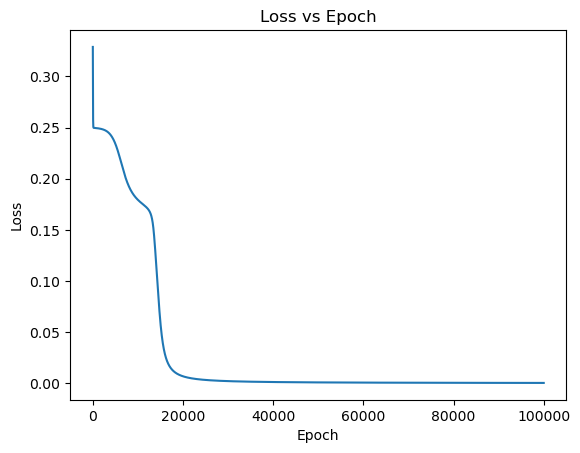

Layer 1
W = [[4.5551668  6.68685525]
 [4.55475988 6.684793  ]]
b = [[-6.97811584 -2.94940197]]
Layer 2
W = [[-10.19336106]
 [  9.48354688]]
b = [[-4.3788884]]


In [7]:
nn_xor_mse = SigmoidNN([2,2,1], x_2, x_2_xor_y, 0.1, 100000, loss_func="mse")
nn_xor_mse.train(print_epoch=10000)
nn_xor_mse.plot_loss()
nn_xor_mse.print_weights_and_biases()

Epoch 0: Loss = 0.7381112930690845, Accuracy = 0.5
Epoch 10000: Loss = 0.265604610417802, Accuracy = 1.0
Epoch 20000: Loss = 0.010117574533654255, Accuracy = 1.0
Epoch 30000: Loss = 0.004915305028626896, Accuracy = 1.0
Epoch 40000: Loss = 0.0032301952558424826, Accuracy = 1.0
Epoch 50000: Loss = 0.002401187225201281, Accuracy = 1.0
Epoch 60000: Loss = 0.0019090965116944022, Accuracy = 1.0
Epoch 70000: Loss = 0.001583580982759616, Accuracy = 1.0
Epoch 80000: Loss = 0.0013524559517733565, Accuracy = 1.0
Epoch 90000: Loss = 0.0011799381787841812, Accuracy = 1.0


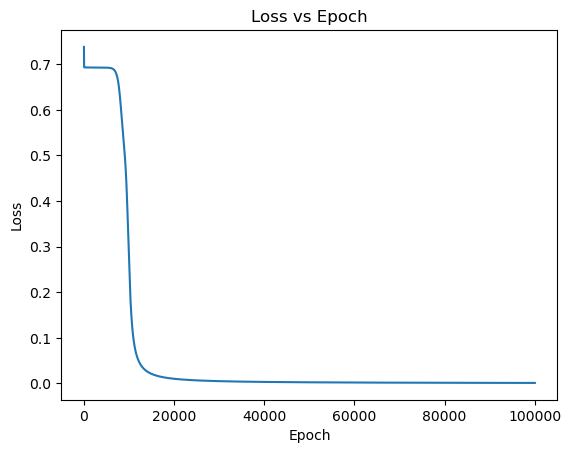

Layer 1
W = [[7.89240064 6.11490147]
 [7.89433628 6.1152634 ]]
b = [[-3.65166664 -9.34213424]]
Layer 2
W = [[ 14.75525064]
 [-15.53771957]]
b = [[-6.98179159]]


In [8]:
nn_xor_bce = SigmoidNN([2,2,1], x_2, x_2_xor_y, 0.1, 100000, loss_func="bce")
nn_xor_bce.train(print_epoch=10000)
nn_xor_bce.plot_loss()
nn_xor_bce.print_weights_and_biases()

Epoch 0: Loss = 0.6256412381930687, Accuracy = 0.25
Epoch 10000: Loss = 0.1754543902393846, Accuracy = 0.75
Epoch 20000: Loss = 0.13195118669889289, Accuracy = 0.875
Epoch 30000: Loss = 0.011888542135531558, Accuracy = 1.0
Epoch 40000: Loss = 0.004086393456635999, Accuracy = 1.0
Epoch 50000: Loss = 0.0023166946922711365, Accuracy = 1.0
Epoch 60000: Loss = 0.0015824560680477338, Accuracy = 1.0
Epoch 70000: Loss = 0.0011895023686268177, Accuracy = 1.0
Epoch 80000: Loss = 0.000947435726117452, Accuracy = 1.0
Epoch 90000: Loss = 0.0007843933052015535, Accuracy = 1.0


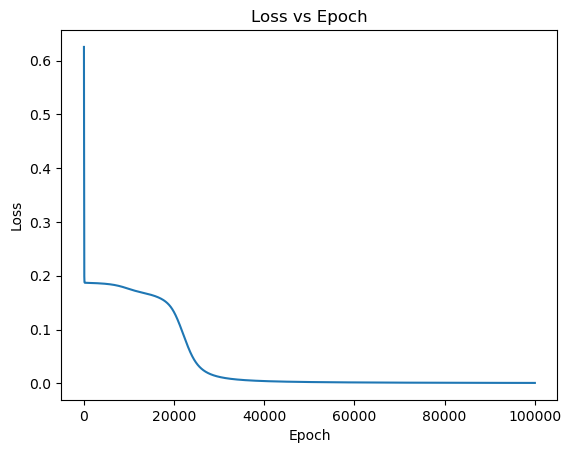

Layer 1
W = [[-0.69718804  6.35854655  4.48345708]
 [ 6.63553148  3.48345344 -3.45576666]
 [-6.18455654 -3.41151264  3.26551181]
 [ 1.3774364   6.34928053  3.85976286]]
b = [[ 2.94269687 -1.77674386 -6.47039228]]
Layer 2
W = [[  9.34791158]
 [-10.06710588]
 [  9.70023424]]
b = [[-4.1214178]]


In [9]:
nn_pal_4_mse = SigmoidNN([4,3,1], x_4, x_4_palindrome_y, 0.1, 100000, loss_func="mse")
nn_pal_4_mse.train(print_epoch=10000)
nn_pal_4_mse.plot_loss()
nn_pal_4_mse.print_weights_and_biases()

Epoch 0: Loss = 1.9179408401112923, Accuracy = 0.25
Epoch 10000: Loss = 0.44836004868368423, Accuracy = 0.8125
Epoch 20000: Loss = 0.2120704912873496, Accuracy = 0.875
Epoch 30000: Loss = 0.18717579305890422, Accuracy = 0.875
Epoch 40000: Loss = 0.1814309577347287, Accuracy = 0.875
Epoch 50000: Loss = 0.17897723958940545, Accuracy = 0.875
Epoch 60000: Loss = 0.177627419526492, Accuracy = 0.875
Epoch 70000: Loss = 0.1767741040705849, Accuracy = 0.875
Epoch 80000: Loss = 0.1761837128221157, Accuracy = 0.875
Epoch 90000: Loss = 0.17574696299362688, Accuracy = 0.875


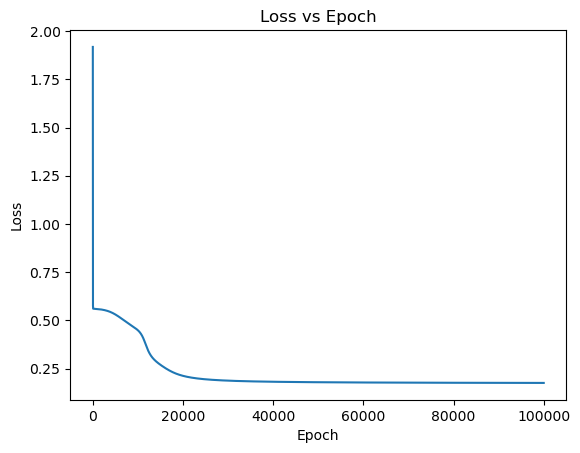

Layer 1
W = [[-2.84894138e-03  7.16535026e+00 -5.15080132e+00]
 [ 4.69818879e+00  6.02676595e+00  5.06688336e+00]
 [ 4.69796712e+00  6.02631886e+00  5.06679898e+00]
 [-2.85236717e-03  7.16746599e+00 -5.15113554e+00]]
b = [[-7.76413867 -3.40568635  7.37846907]]
Layer 2
W = [[  8.96331801]
 [-12.46290536]
 [-12.65278888]]
b = [[17.61604065]]


In [10]:
nn_pal_4_bce = SigmoidNN([4,3,1], x_4, x_4_palindrome_y, 0.1, 100000, loss_func="bce")
nn_pal_4_bce.train(print_epoch=10000)
nn_pal_4_bce.plot_loss()
nn_pal_4_bce.print_weights_and_biases()

Epoch 0: Loss = 0.5860801342907249, Accuracy = 0.25
Epoch 10000: Loss = 0.18336046077040802, Accuracy = 0.75
Epoch 20000: Loss = 0.16717998838435516, Accuracy = 0.8125
Epoch 30000: Loss = 0.1463763537031345, Accuracy = 0.8125
Epoch 40000: Loss = 0.12587934245958365, Accuracy = 0.8125
Epoch 50000: Loss = 0.12060762004753167, Accuracy = 0.8125
Epoch 60000: Loss = 0.09037336668570456, Accuracy = 0.875
Epoch 70000: Loss = 0.07083278642803495, Accuracy = 0.875
Epoch 80000: Loss = 0.06620378652088074, Accuracy = 0.90625
Epoch 90000: Loss = 0.06456955802285468, Accuracy = 0.9375
Epoch 100000: Loss = 0.06359073001009255, Accuracy = 0.96875
Epoch 110000: Loss = 0.06220753849753176, Accuracy = 1.0
Epoch 120000: Loss = 0.048027475267616, Accuracy = 1.0
Epoch 130000: Loss = 0.03734394289877119, Accuracy = 1.0
Epoch 140000: Loss = 0.025494568701517634, Accuracy = 1.0
Epoch 150000: Loss = 0.018545984260874657, Accuracy = 1.0
Epoch 160000: Loss = 0.014975849838056096, Accuracy = 1.0
Epoch 170000: Los

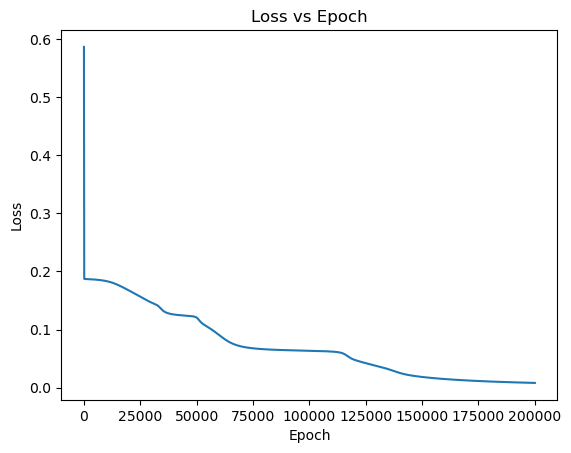

Layer 1
W = [[ 6.28647164e+00 -1.08472731e-02 -4.36740060e+00]
 [ 1.47611699e+00  5.94967190e+00  1.47771606e+00]
 [-2.18052487e-03 -1.29231448e-02 -1.51724545e-03]
 [ 1.47611705e+00  5.94967331e+00  1.47771611e+00]
 [ 6.28861368e+00 -1.08324317e-02 -4.36741978e+00]]
b = [[ -1.96813647 -10.40196012   6.76107018]]
Layer 2
W = [[-15.78530121]
 [ 12.18558748]
 [-15.79233143]]
b = [[19.43005878]]


In [11]:
nn_pal_5_mse = SigmoidNN([5,3,1], x_5, x_5_palindrome_y, 0.1, 200000, loss_func="mse")
nn_pal_5_mse.train(print_epoch=10000)
nn_pal_5_mse.plot_loss()
nn_pal_5_mse.print_weights_and_biases()

Epoch 0: Loss = 1.8717224168011894, Accuracy = 0.25
Epoch 10000: Loss = 0.024115692845288104, Accuracy = 1.0
Epoch 20000: Loss = 0.005888968551920036, Accuracy = 1.0
Epoch 30000: Loss = 0.0032758236555554578, Accuracy = 1.0
Epoch 40000: Loss = 0.002254795644148106, Accuracy = 1.0
Epoch 50000: Loss = 0.0017142383808691443, Accuracy = 1.0
Epoch 60000: Loss = 0.0013806426673777343, Accuracy = 1.0
Epoch 70000: Loss = 0.0011546459593676658, Accuracy = 1.0
Epoch 80000: Loss = 0.0009916018103797743, Accuracy = 1.0
Epoch 90000: Loss = 0.0008685160492858012, Accuracy = 1.0


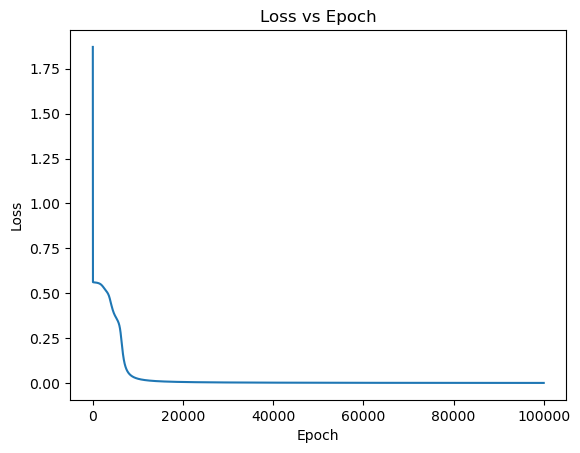

Layer 1
W = [[ 0.42340054  9.06081102  6.1454497 ]
 [ 8.20405641  4.82883949 -4.83761924]
 [ 0.22616336 -0.02538868 -0.10818153]
 [-7.7307756  -4.80211733  4.6049675 ]
 [ 0.14108988  9.08222852  6.20300721]]
b = [[ 3.55244659 -2.56666401 -9.55454722]]
Layer 2
W = [[ 15.20285515]
 [-16.58250406]
 [ 16.08453289]]
b = [[-7.01724541]]


In [12]:
nn_pal_5_bce = SigmoidNN([5,3,1], x_5, x_5_palindrome_y, 0.2, 100000, loss_func="bce")
nn_pal_5_bce.train(print_epoch=10000)
nn_pal_5_bce.plot_loss()
nn_pal_5_bce.print_weights_and_biases()

Epoch 0: Loss = 0.4252143031984418, Accuracy = 0.5
Epoch 10000: Loss = 0.249958654648749, Accuracy = 0.5625
Epoch 20000: Loss = 0.24986184566166197, Accuracy = 0.5625
Epoch 30000: Loss = 0.24882239464579364, Accuracy = 0.5625
Epoch 40000: Loss = 0.08395455141374948, Accuracy = 0.9375
Epoch 50000: Loss = 0.05704817620836197, Accuracy = 0.9375
Epoch 60000: Loss = 0.04049419121207541, Accuracy = 0.9375
Epoch 70000: Loss = 0.006148914163451798, Accuracy = 1.0
Epoch 80000: Loss = 0.002714945190535659, Accuracy = 1.0
Epoch 90000: Loss = 0.0017022173734071412, Accuracy = 1.0
Epoch 100000: Loss = 0.0012288417785113624, Accuracy = 1.0
Epoch 110000: Loss = 0.0009571417986759153, Accuracy = 1.0
Epoch 120000: Loss = 0.000781751647193445, Accuracy = 1.0
Epoch 130000: Loss = 0.000659546421456604, Accuracy = 1.0
Epoch 140000: Loss = 0.0005697019183081471, Accuracy = 1.0
Epoch 150000: Loss = 0.00050096528776417, Accuracy = 1.0
Epoch 160000: Loss = 0.000446736975125895, Accuracy = 1.0
Epoch 170000: Los

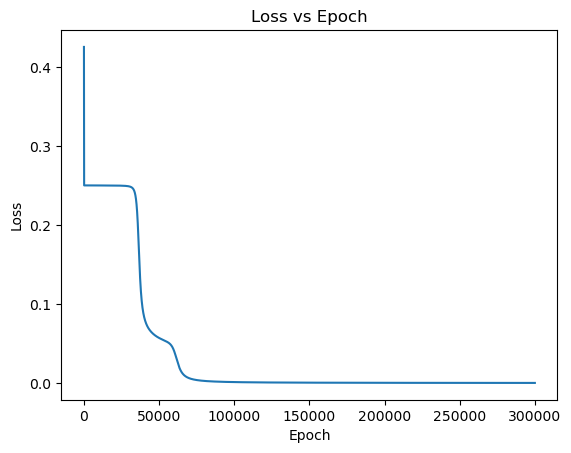

Layer 1
W = [[ 6.6378428  -2.12963241  6.35741541  3.44055679  7.32740671]
 [ 4.49070539  3.26799642  6.26383522  3.30455055  5.363271  ]
 [-3.33637393  6.53329269  6.33808957  3.5198811   7.57021946]
 [ 7.09842848  6.74152346  6.07581482  3.61942842 -5.58236139]]
b = [[ -4.12125828  -4.12487919  -7.35303816 -12.89728182  -3.07836698]]
Layer 2
W = [[-9.72943217]
 [-9.72667752]
 [15.57868058]
 [12.70752618]
 [-9.64274252]]
b = [[8.21349946]]


In [13]:
nn_even_4 = SigmoidNN([4,5,1], x_4, x_4_even_parity_y, 0.2, 300000, loss_func="mse")
nn_even_4.train(print_epoch=10000)
nn_even_4.plot_loss()
nn_even_4.print_weights_and_biases()

Epoch 0: Loss = 0.48520071881092625, Accuracy = 0.5
Epoch 10000: Loss = 0.25002096723936235, Accuracy = 0.46875
Epoch 20000: Loss = 0.2500074466827808, Accuracy = 0.5
Epoch 30000: Loss = 0.24999878543483828, Accuracy = 0.59375
Epoch 40000: Loss = 0.2499905547207843, Accuracy = 0.53125
Epoch 50000: Loss = 0.24998051713599218, Accuracy = 0.5625
Epoch 60000: Loss = 0.2499661306831787, Accuracy = 0.5
Epoch 70000: Loss = 0.24994319017967193, Accuracy = 0.5
Epoch 80000: Loss = 0.24990321859165648, Accuracy = 0.59375
Epoch 90000: Loss = 0.24982512237633445, Accuracy = 0.5625
Epoch 100000: Loss = 0.24963845595063247, Accuracy = 0.59375
Epoch 110000: Loss = 0.24898130243802147, Accuracy = 0.53125
Epoch 120000: Loss = 0.244077325462465, Accuracy = 0.5
Epoch 130000: Loss = 0.2058509318817609, Accuracy = 0.5
Epoch 140000: Loss = 0.15780341689294056, Accuracy = 0.84375
Epoch 150000: Loss = 0.12963268648078183, Accuracy = 0.84375
Epoch 160000: Loss = 0.07441127393426392, Accuracy = 0.96875
Epoch 170

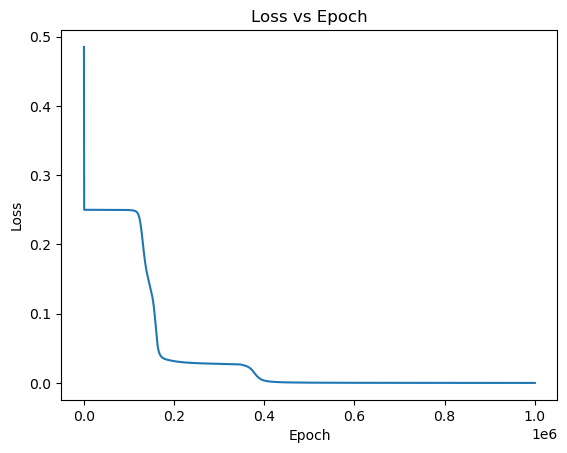

Layer 1
W = [[2.78474039 6.72115644 5.17592027 2.31526888 5.38673571 3.36314024
  3.06226796]
 [2.78467018 6.68179005 5.17494061 2.0071611  5.38932071 3.73258025
  2.94962666]
 [2.78498912 6.71987775 5.17664683 2.09718868 5.39414486 3.39789463
  3.21958974]
 [2.78482331 6.73891919 5.17658484 2.41598987 5.38706181 3.26874097
  3.10727175]
 [2.78495678 6.74072548 5.17695754 2.31268648 5.39086272 3.29898626
  3.16534314]]
b = [[-12.71415843 -10.1625189  -17.57183452  -1.05000388 -12.9874262
   -1.54295661  -1.3819066 ]]
Layer 2
W = [[-14.21457256]
 [ 14.64805412]
 [ 14.30385723]
 [ -3.21872947]
 [-14.00103524]
 [ -6.25155427]
 [ -5.22794275]]
b = [[7.04223443]]


In [14]:
nn_even_5 = SigmoidNN([5,7,1], x_5, x_5_even_parity_y, 0.1, 1000000, loss_func="mse")
nn_even_5.train(print_epoch=10000)
nn_even_5.plot_loss()
nn_even_5.print_weights_and_biases()

Epoch 0: Loss = 0.4819414974813774, Accuracy = 0.5
Epoch 10000: Loss = 0.2500145621476665, Accuracy = 0.5
Epoch 20000: Loss = 0.250007083099201, Accuracy = 0.5625
Epoch 30000: Loss = 0.2500043202687524, Accuracy = 0.5625
Epoch 40000: Loss = 0.25000301902017913, Accuracy = 0.53125
Epoch 50000: Loss = 0.25000226926069646, Accuracy = 0.53125
Epoch 60000: Loss = 0.25000174769906897, Accuracy = 0.46875
Epoch 70000: Loss = 0.25000132932311026, Accuracy = 0.4375
Epoch 80000: Loss = 0.25000096270357763, Accuracy = 0.46875
Epoch 90000: Loss = 0.2500006247803003, Accuracy = 0.46875
Epoch 100000: Loss = 0.25000030378883653, Accuracy = 0.4375
Epoch 110000: Loss = 0.2499999926605984, Accuracy = 0.46875
Epoch 120000: Loss = 0.24999968639685724, Accuracy = 0.4375
Epoch 130000: Loss = 0.24999938097323648, Accuracy = 0.40625
Epoch 140000: Loss = 0.2499990728446426, Accuracy = 0.40625
Epoch 150000: Loss = 0.24999875869134766, Accuracy = 0.40625
Epoch 160000: Loss = 0.24999843526418775, Accuracy = 0.4062

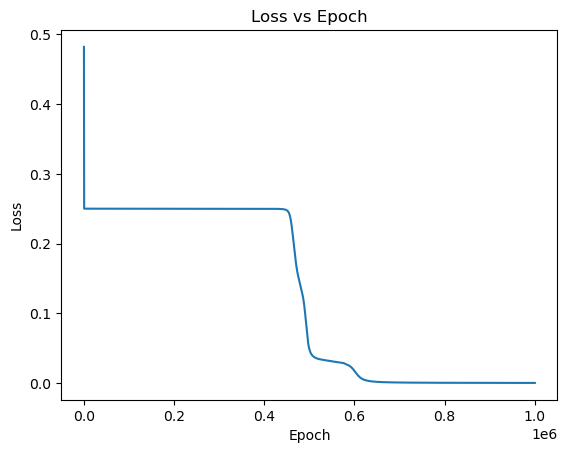

Layer 1
W = [[ 0.97348771  6.00409053  3.75108215  4.8810552   6.99408101  2.70438078]
 [ 1.13741749  6.00322719  3.75008817  4.88125322  6.99799879  2.70431213]
 [ 1.5646101  -4.97140677  9.93495975  5.31831309  6.31312775  2.83109089]
 [ 0.98927606  6.004761    3.75119923  4.88118532  6.99847511  2.7043994 ]
 [ 1.07715655  6.00347778  3.75051353  4.88117106  6.99769995  2.70433473]]
b = [[ -0.02604345  -3.5627835   -8.9280302  -17.0979824   -9.3526979
  -12.48229975]]
Layer 2
W = [[ -0.18252737]
 [-11.98598703]
 [-13.7558927 ]
 [ 13.50789801]
 [ 14.66449256]
 [-13.79141431]]
b = [[4.89893425]]


In [15]:
nn_even_5 = SigmoidNN([5,6,1], x_5, x_5_even_parity_y, 0.1, 1000000, loss_func="mse")
nn_even_5.train(print_epoch=10000)
nn_even_5.plot_loss()
nn_even_5.print_weights_and_biases()

Epoch 0: Loss = 0.47666462522325914, Accuracy = 0.5
Epoch 10000: Loss = 0.2500081769993402, Accuracy = 0.5
Epoch 20000: Loss = 0.25000405001171877, Accuracy = 0.5
Epoch 30000: Loss = 0.25000201237860276, Accuracy = 0.46875
Epoch 40000: Loss = 0.25000084661766003, Accuracy = 0.46875
Epoch 50000: Loss = 0.25000011595967, Accuracy = 0.46875
Epoch 60000: Loss = 0.24999961209848362, Accuracy = 0.40625
Epoch 70000: Loss = 0.24999922409489256, Accuracy = 0.40625
Epoch 80000: Loss = 0.24999888816744686, Accuracy = 0.46875
Epoch 90000: Loss = 0.24999856336300072, Accuracy = 0.5
Epoch 100000: Loss = 0.24999821824069698, Accuracy = 0.53125
Epoch 110000: Loss = 0.24999782250918165, Accuracy = 0.53125
Epoch 120000: Loss = 0.24999734041584876, Accuracy = 0.5625
Epoch 130000: Loss = 0.24999672370265372, Accuracy = 0.5625
Epoch 140000: Loss = 0.24999590201381391, Accuracy = 0.625
Epoch 150000: Loss = 0.24999476788778535, Accuracy = 0.59375
Epoch 160000: Loss = 0.249993151587881, Accuracy = 0.5625
Epoc

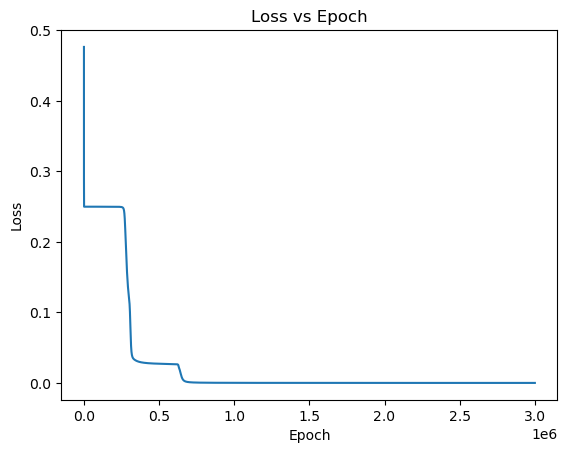

Layer 1
W = [[3.04851546 5.53502301 6.73591118 5.68806066 5.02284785]
 [3.04850332 5.53498315 6.7367691  5.68802735 5.02982938]
 [3.04866855 5.53568657 6.74147773 5.69020119 5.02134963]
 [3.04880811 5.53627837 6.74499625 5.69200289 5.01142666]
 [3.04858173 5.53527844 6.73469799 5.68863037 5.00278422]]
b = [[-13.92735398 -18.94504847 -10.24287308 -13.85587949  -2.3865428 ]]
Layer 2
W = [[-15.73861117]
 [ 15.40531125]
 [ 14.04453826]
 [-14.9306931 ]
 [-12.13495747]]
b = [[5.59237157]]


In [17]:
nn_even_5 = SigmoidNN([5,5,1], x_5, x_5_even_parity_y, 0.1, 3000000, loss_func="mse")
nn_even_5.train(print_epoch=10000)
nn_even_5.plot_loss()
nn_even_5.print_weights_and_biases()